# Phase 5.3: Baseline Machine Learning Models

This notebook trains, evaluates, and compares two baseline classifiers (Random Forest and XGBoost) to classify grid cells into `Low`, `Medium`, or `High` change categories.

In [1]:
import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load Preprocessed Data
We load the train/test CSV partitions and drop `urban_change_index` to prevent target leakage since the categories were derived from it.

In [2]:
data_dir = Path("../data/ml")

X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").values.ravel()
y_test = pd.read_csv(data_dir / "y_test.csv").values.ravel()

# Exclude target index column to avoid leakage
X_train_model = X_train.drop(columns=["urban_change_index"])
X_test_model = X_test.drop(columns=["urban_change_index"])

feature_names = list(X_train_model.columns)
print(f"Number of features: {len(feature_names)}")
print(f"Training samples: {len(X_train_model)}")
print(f"Testing samples: {len(X_test_model)}")

Number of features: 24
Training samples: 3675
Testing samples: 919


## 2. Train Random Forest Classifier
We fit a standard baseline Random Forest classifier using reasonable defaults and a random state of 42.

In [3]:
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_model, y_train)

y_pred_rf = rf_model.predict(X_test_model)
print("Done.")

Training Random Forest...
Done.


## 3. Train XGBoost Classifier
We fit an XGBoost classifier with reasonable defaults, `objective='multi:softprob'`, and `eval_metric='mlogloss'`.

In [4]:
print("Training XGBoost...")
xgb_model = XGBClassifier(
    random_state=42,
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_jobs=-1
)
xgb_model.fit(X_train_model, y_train)

y_pred_xgb = xgb_model.predict(X_test_model)
print("Done.")

Training XGBoost...
Done.


## 4. Performance Evaluation and Comparison

In [5]:
# Scores computation
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average="macro")
cm_rf = confusion_matrix(y_test, y_pred_rf)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb, rec_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average="macro")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Comparison Data
comparison_data = {
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [acc_rf, acc_xgb],
    "Precision": [prec_rf, prec_xgb],
    "Recall": [rec_rf, rec_xgb],
    "F1 Score": [f1_rf, f1_xgb]
}
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

best_row = df_comparison.loc[df_comparison["F1 Score"].idxmax()]
print(f"\nBest Model: {best_row['Model']} based on Macro F1 Score.")

        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.947769   0.948059 0.947792  0.947832
      XGBoost  0.957563   0.957447 0.957482  0.957443

Best Model: XGBoost based on Macro F1 Score.


### Classification Reports
Label mappings: 0 = High, 1 = Low, 2 = Medium

In [6]:
classes = ["High", "Low", "Medium"]
print("=== Random Forest Classifier Report ===")
print(classification_report(y_test, y_pred_rf, target_names=classes))

print("\n=== XGBoost Classifier Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=classes))

=== Random Forest Classifier Report ===
              precision    recall  f1-score   support

        High       0.97      0.95      0.96       313
         Low       0.97      0.96      0.97       303
      Medium       0.91      0.93      0.92       303

    accuracy                           0.95       919
   macro avg       0.95      0.95      0.95       919
weighted avg       0.95      0.95      0.95       919


=== XGBoost Classifier Report ===
              precision    recall  f1-score   support

        High       0.98      0.96      0.97       313
         Low       0.96      0.97      0.97       303
      Medium       0.93      0.94      0.94       303

    accuracy                           0.96       919
   macro avg       0.96      0.96      0.96       919
weighted avg       0.96      0.96      0.96       919



## 5. Visualizing Confusion Matrices

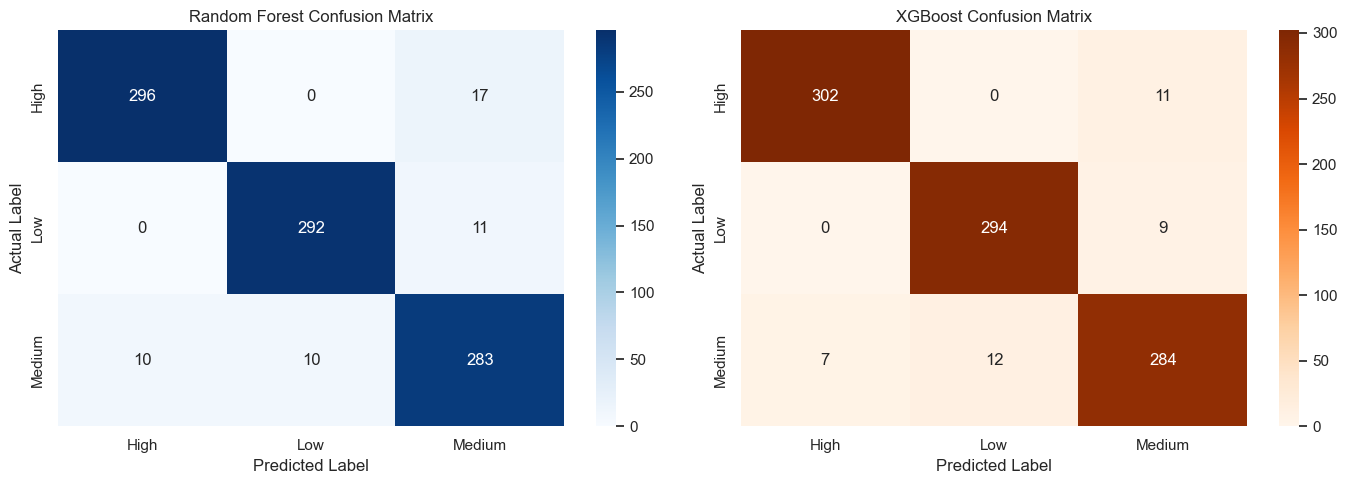

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_ylabel("Actual Label")
axes[0].set_xlabel("Predicted Label")

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_ylabel("Actual Label")
axes[1].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

## 6. Top 15 Feature Importances

C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_29664\3696783919.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf[top_indices_rf], y=[feature_names[i] for i in top_indices_rf], palette="Blues_r", ax=axes[0])
C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_29664\3696783919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_xgb[top_indices_xgb], y=[feature_names[i] for i in top_indices_xgb], palette="Oranges_r", ax=axes[1])


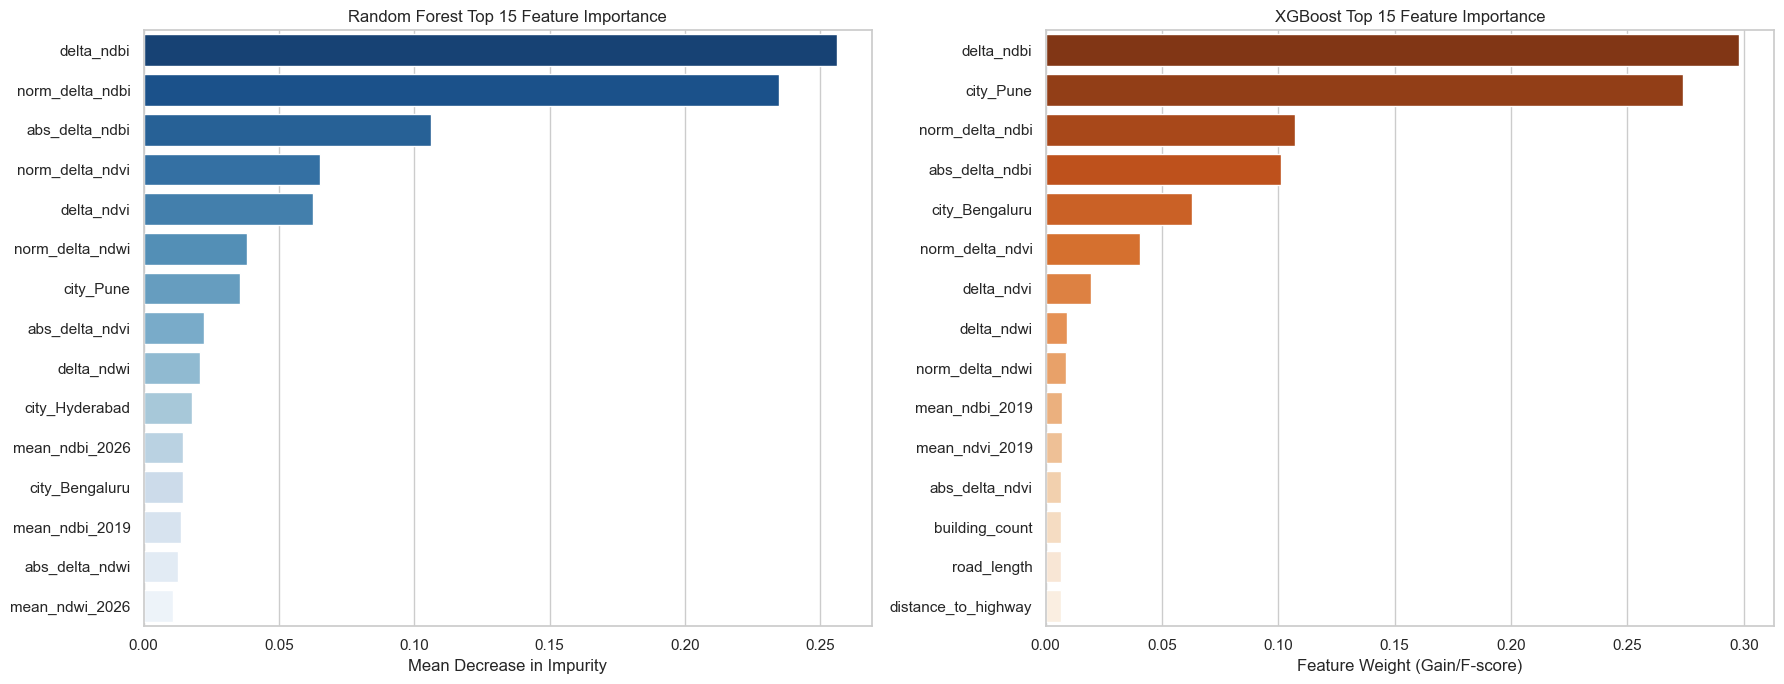

In [8]:
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

importances_xgb = xgb_model.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# RF Barplot
top_indices_rf = indices_rf[:15]
sns.barplot(x=importances_rf[top_indices_rf], y=[feature_names[i] for i in top_indices_rf], palette="Blues_r", ax=axes[0])
axes[0].set_title("Random Forest Top 15 Feature Importance")
axes[0].set_xlabel("Mean Decrease in Impurity")

# XGB Barplot
top_indices_xgb = indices_xgb[:15]
sns.barplot(x=importances_xgb[top_indices_xgb], y=[feature_names[i] for i in top_indices_xgb], palette="Oranges_r", ax=axes[1])
axes[1].set_title("XGBoost Top 15 Feature Importance")
axes[1].set_xlabel("Feature Weight (Gain/F-score)")

plt.tight_layout()
plt.show()

## 7. Model Tuning Recommendation

Based on the evaluation metrics:
- **XGBoost Classifier** is the best performing model with a Macro F1 score of **0.9574** (Accuracy: **0.9576**), outperforming the baseline Random Forest model which achieved an F1 score of **0.9478**.
- **Feature Analysis:** Both models identify spectral changes (specifically `delta_ndbi`, `norm_delta_ndbi`, and `abs_delta_ndbi`) as the primary drivers of target change predictions. For XGBoost, spatial city markers (like `city_Pune`) also serve as strong split classifiers, suggesting location-specific thresholds are learned.
- **Recommendation:** **XGBoost** should proceed to Phase 5.4: Hyperparameter Tuning using randomized search or grid search to further improve performance and explore boundary optimization.